# 03 · SINDy-PI (Parallel / Implicit)

Many real systems have **rational** right-hand sides. Michaelis–Menten enzyme kinetics
deplete substrate $S$ at the saturating rate

$$\frac{dS}{dt} = -\,\frac{V_{\max}\,S}{K_m + S}.$$

A *polynomial* library can never represent this exactly. **SINDy-PI** rewrites the
problem in **implicit** form so the unknown can sit on both sides:

$$(K_m + S)\,\frac{dS}{dt} = -V_{\max}\,S
\;\;\Longleftrightarrow\;\;
K_m\,\dot S + S\,\dot S + V_{\max}\,S = 0,$$

then sparsely regresses each candidate (including $\dot S$ products) against the others.
We use `pysindy`'s `PDELibrary(implicit_terms=True)` + the `SINDyPI` optimizer
(`cvxpy`-backed). Ground truth here: $V_{\max}=1.0,\ K_m=0.5$.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the shared tutorial package (src/sparse_demos) importable regardless of
# whether the notebook is launched from notebooks/ or the repo root.
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

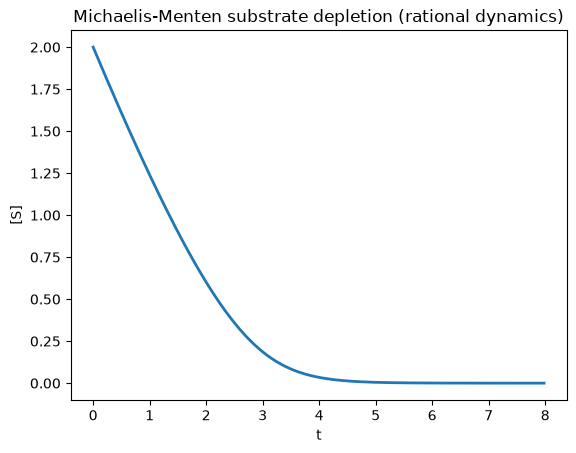

In [3]:
from sparse_demos import systems
import pysindy as ps

t, X = systems.simulate_mm(t_span=(0, 8), dt=0.02, s0=2.0, vmax=1.0, km=0.5)
S = X[:, :1]            # substrate only, shape (n, 1)
dt = t[1] - t[0]
plt.plot(t, S, lw=2); plt.xlabel("t"); plt.ylabel("[S]")
plt.title("Michaelis-Menten substrate depletion (rational dynamics)"); plt.show()

## First, watch vanilla SINDy fail

Given only a polynomial library, SINDy returns a polynomial *approximation* of the
rational curve — the wrong functional form.

In [4]:
poly = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=3),
                optimizer=ps.STLSQ(threshold=0.01))
poly.fit(S, t=dt, feature_names=["S"])
print("Vanilla SINDy (polynomial) approximation of a rational law:")
poly.print()
print("\n-> a degree-3 polynomial fudge, not  dS/dt = -Vmax*S/(Km+S).")

Vanilla SINDy (polynomial) approximation of a rational law:
(S)' = -0.007 1 + -1.456 S +  1.044 S^2 + -0.262 S^3

-> a degree-3 polynomial fudge, not  dS/dt = -Vmax*S/(Km+S).


## SINDy-PI recovers the implicit rational law

In [5]:
pde_lib = ps.PDELibrary(
    function_library=ps.PolynomialLibrary(degree=2, include_bias=False),
    derivative_order=1, temporal_grid=t,
    implicit_terms=True, include_bias=True,
)
opt = ps.SINDyPI(reg_weight_lam=1e-4, regularizer="l1",
                 tol=1e-10, max_iter=20000, normalize_columns=False)
pi = ps.SINDy(feature_library=pde_lib, optimizer=opt)
pi.fit(S, t=dt, feature_names=["S"])

print("Library features:", pi.get_feature_names())
print("\nSINDy-PI implicit equations (each candidate as LHS):")
pi.print(precision=3)

Model  0


Model  1
Model  2
Model  3


Model  4
Model  5
Library features: ['1', 'S', 'S^2', 'S_t', 'SS_t', 'S^2S_t']

SINDy-PI implicit equations (each candidate as LHS):
(1) = -0.052 1 + -68022.725 S +  0.284 S^2 + -34015.366 S_t + -68020.881 SS_t
(S) = -0.500 S_t + -1.000 SS_t
(S^2) = -0.500 SS_t + -1.000 S^2S_t
(S_t) = -2.000 S + -2.000 SS_t
(SS_t) = -1.000 S + -0.500 S_t
(S^2S_t) = -1.000 S^2 + -0.500 SS_t


Read the **`(S) = ...`** row:

$$S = -0.5\,\dot S - 1.0\,(S\,\dot S)
\;\;\Longleftrightarrow\;\;
(0.5 + S)\,\dot S = -1.0\,S
\;\;\Longleftrightarrow\;\;
(K_m + S)\,\dot S = -V_{\max}\,S,$$

with $K_m = 0.5,\ V_{\max} = 1.0$ — the exact rational law, recovered.

**Takeaway.** SINDy-PI handles rational/implicit dynamics that defeat polynomial SINDy.
But notice we hand-picked a single state and library. When a system mixes *algebraic
constraints* with dynamics (a DAE), we want a method that discovers that structure
itself. → `04_sodas_dae.ipynb`